In [27]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW, AutoModelForMaskedLM
from transformers import BertForSequenceClassification
import torch
from transformers import AdamW
from transformers import get_scheduler
from transformers import Trainer
from transformers import BertTokenizer
import numpy as np
import pandas as pd
import csv


batch_size = 35

#tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
tokenizer = BertTokenizer.from_pretrained("/share/home/320346/chinese-bert-wwm/")

df = pd.read_csv("/share/home/320346/est_sample.csv", encoding = "utf_8_sig", on_bad_lines='skip', encoding_errors='ignore')

# replace the symbol '-' to '.' in soc_code column, and convert soc_code to int
df['soc_code'] = df['soc_code'].str.replace('-', '')

# replace 'Yes' with True and NaN with False using the fillna() and astype() methods
df['true_ind'] = df['true_ind'].fillna(False).astype(bool)









#df = df.groupby('soc_code', group_keys=False).apply(lambda x: x.sample(min(len(x), 50)))
# keep soc_code is 111010' or '111020' in the df
#df = df[df['soc_code'].isin(['111010', '111020', '253010'])]








# generate a new column 'soc_code1' with value to recode the 'soc_code' in ascending order
# Create a dictionary to map unique soc_codes to sequential integer labels
unique_soc_codes = sorted(df['soc_code'].unique())
soc_code_dict  = {soc_code: i for i, soc_code in enumerate(unique_soc_codes)}







from sklearn.model_selection import train_test_split
train_df_sample, temp_df_sample = train_test_split(df, test_size=0.4, random_state=42)
valid_df_sample, test_df_sample = train_test_split(temp_df_sample, test_size=0.5, random_state=42)

train_df_sample.to_csv("/share/home/320346/train_df_sample.csv", index=False, encoding = "utf_8_sig", header=True)
test_df_sample.to_csv("/share/home/320346/test_df_sample.csv", index=False, encoding = "utf_8_sig", header=True)
valid_df_sample.to_csv("/share/home/320346/valid_df_sample.csv", index=False, encoding = "utf_8_sig", header=True)


# drop index column, 'true_ind' and 'sample' columns
train_df_sample = train_df_sample.drop(['Unnamed: 0'], axis = 1)
# keep if 'true_ind' is False
train_df_sample = train_df_sample[train_df_sample['true_ind'] == True]
# Generate a new column 'soc_code1' with the mapped values from 'soc_code'
train_df_sample['soc_code1'] = train_df_sample['soc_code'].map(soc_code_dict)


# drop index column, 'true_ind' and 'sample' columns
test_df_sample = test_df_sample.drop(['Unnamed: 0'], axis = 1)
# keep if 'true_ind' is False
test_df_sample = test_df_sample[test_df_sample['true_ind'] == True]
# Generate a new column 'soc_code1' with the mapped values from 'soc_code' for the test set
test_df_sample['soc_code1'] = test_df_sample['soc_code'].map(soc_code_dict)

# drop index column, 'true_ind' and 'sample' columns
valid_df_sample = valid_df_sample.drop(['Unnamed: 0'], axis = 1)
# keep if 'true_ind' is False
valid_df_sample = valid_df_sample[valid_df_sample['true_ind'] == True]
# Generate a new column 'soc_code1' with the mapped values from 'soc_code' for the validation set
valid_df_sample['soc_code1'] = valid_df_sample['soc_code'].map(soc_code_dict)








# Tokenize the text and convert it into input features
train_titles = train_df_sample['工作名称'].astype(str).tolist()
train_texts = train_df_sample['工作描述'].astype(str).tolist()
train_labels = train_df_sample['soc_code1'].tolist()


test_titles = test_df_sample['工作名称'].astype(str).tolist()
test_texts = test_df_sample['工作描述'].astype(str).tolist()
test_labels = test_df_sample['soc_code1'].tolist()


valid_titles = valid_df_sample['工作名称'].astype(str).tolist()
valid_texts = valid_df_sample['工作描述'].astype(str).tolist()
valid_labels = valid_df_sample['soc_code1'].tolist()










def assign_weight(true_ind):
    if true_ind:
        return 1.0
    else:
        return 0.5
    
# Assuming you have a column called 'true_ind' in your dataset with boolean values
# True for credible labels and False for less credible labels
train_df_sample['weight'] = train_df_sample['true_ind'].apply(assign_weight)
test_df_sample['weight'] = test_df_sample['true_ind'].apply(assign_weight)
valid_df_sample['weight'] = valid_df_sample['true_ind'].apply(assign_weight)

# Extract the weights
train_weights = train_df_sample['weight'].tolist()
valid_weights = valid_df_sample['weight'].tolist()
test_weights = test_df_sample['weight'].tolist()







from torch.utils.data import Dataset

# Create the JobPostingDataset class
class JobPostingDataset(Dataset):
    def __init__(self, titles, descriptions, labels, weights, tokenizer, max_length):
        self.titles = titles
        self.descriptions = descriptions
        self.labels = labels
        self.weights = weights
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.titles)

    def __getitem__(self, idx):
        title = self.titles[idx]
        description = self.descriptions[idx]
        label = self.labels[idx]
        weight = self.weights[idx]

        # Concatenate title and description, repeat the title to give it more importance
        repeat_title = 2  # Adjust this value to control the importance of the title
        text = (title + " ") * repeat_title + description

        # Tokenize the text
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        # Return a tuple of the input tensors, label, and weight
        return (
            encoding["input_ids"].squeeze(0),
            encoding["attention_mask"].squeeze(0),
            torch.tensor(label, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float),
        )









import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup

# Create the datasets
max_length = 512
train_dataset = JobPostingDataset(train_titles, train_texts, train_labels, train_weights, tokenizer, max_length)
valid_dataset = JobPostingDataset(valid_titles, valid_texts, valid_labels, valid_weights, tokenizer, max_length)
test_dataset = JobPostingDataset(test_titles, test_texts, test_labels, test_weights, tokenizer, max_length)

# Create the data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)








def evaluate(model, valid_loader, device, loss_fn):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for batch in valid_loader:
            inputs = batch[0].to(device)
            masks = batch[1].to(device)
            labels = batch[2].to(device)
            weights = batch[3].to(device)

            logits = model(inputs, attention_mask=masks).logits
            batch_loss = loss_fn(logits, labels)
            weighted_batch_loss = batch_loss * weights
            loss = torch.mean(weighted_batch_loss)

            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches










# Define the model, the optimizer, and the learning rate scheduler
num_labels = len(train_df_sample['soc_code1'].unique())

model = BertForSequenceClassification.from_pretrained("/share/home/320346/chinese-bert-wwm/", num_labels=num_labels)
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
num_epochs = 30
num_training_steps = num_epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

unique_labels = train_df_sample['soc_code1'].unique()
class_weights = compute_class_weight('balanced', classes=unique_labels, y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)

















early_stopping_patience = 3
# This line initializes a counter variable called num_epochs_without_improvement that keeps track of the number of consecutive epochs without an improvement in validation loss. 
# The counter is set to 0 at the beginning of the training process and is incremented by 1 whenever there is no improvement in the validation loss. If the validation loss improves in a particular epoch, the counter is reset to 0.
num_epochs_without_improvement = 0
# During the training loop, if num_epochs_without_improvement becomes equal to or greater than early_stopping_patience, the training will be stopped. 
# This way, the training process can be terminated early when the model starts overfitting, or when there is no significant improvement in the validation loss.
best_valid_loss = float('inf')

# Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Initialize lists to store losses
train_losses = []

# Utilize multiple GPUs with DataParallel
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)

# Pass the computed class_weights to the CrossEntropyLoss function:
# Create a loss function that doesn't reduce the losses right away and pass class_weights
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device), reduction='none')
# By incorporating class weights into the loss function, the model will pay more attention to the minority classes during training. 

model.train()
for epoch in range(num_epochs):
    epoch_train_loss = 0
    num_batches = 0
    for batch in train_loader:
        inputs = batch[0].to(device)
        masks = batch[1].to(device)
        labels = batch[2].to(device)
        weights = batch[3].to(device)  # Assuming the weights are the 4th element in the batch

        optimizer.zero_grad()

        logits = model(inputs, attention_mask=masks).logits

        # Compute the loss for each sample
        batch_loss = loss_fn(logits, labels)

        # Multiply the loss by the corresponding weight
        weighted_batch_loss = batch_loss * weights

        # Average the weighted losses
        loss = torch.mean(weighted_batch_loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Add the current batch loss to the epoch_train_loss
        epoch_train_loss += loss.item()
        num_batches += 1

    # Calculate average loss for the current epoch and append it to the train_losses list
    epoch_train_loss /= num_batches
    train_losses.append(epoch_train_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_train_loss:.4f}")

    # Evaluate the model on the validation set
    valid_loss = evaluate(model, valid_loader, device, loss_fn)
    print(f"Validation Loss: {valid_loss:.4f}")

    # Save the best model based on the validation loss
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        if isinstance(model, torch.nn.DataParallel):
            model.module.save_pretrained("/share/home/320346/bert_robust_model")
        else:
            model.save_pretrained("/share/home/320346/bert_robust_model")
        num_epochs_without_improvement = 0
    else:
        num_epochs_without_improvement += 1

    # Check the stopping condition and break the loop if needed
    if num_epochs_without_improvement >= early_stopping_patience:
        print("Early stopping due to no improvement in validation loss.")
        break

C:\Users\DELL\AppData\Local\Temp\ipykernel_35576\3467390924.py:13: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("G:/Data/job_posting/processed/finetune/est_sample.csv", encoding = "utf_8_sig", on_bad_lines='skip', encoding_errors='ignore')


In [28]:
from sklearn.metrics import classification_report
import pandas as pd

# Evaluate the model and store predictions
model.eval()

predictions = []
true_labels = []

# Create a reverse mapping dictionary to convert the sequential labels back to SOC labels
reverse_soc_code_dict = {v: k for k, v in soc_code_dict.items()}

with torch.no_grad():
    for batch in test_loader:
        inputs = batch[0].to(device)
        masks = batch[1].to(device)
        labels = batch[2].to(device)

        logits = model(inputs, attention_mask=masks).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = labels.cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(labels)

# Convert predictions and true_labels into NumPy arrays
predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Map the sequential labels back to the original SOC codes
soc_predictions = [reverse_soc_code_dict[p] for p in predictions]
soc_true_labels = [reverse_soc_code_dict[l] for l in true_labels]

# Compute classification report
unique_labels = sorted(list(set(soc_true_labels).union(set(soc_predictions))))
report = classification_report(soc_true_labels, soc_predictions, labels=unique_labels, output_dict=True)

# Convert report to a pandas DataFrame
report_df = pd.DataFrame(report).transpose()

# Print the report
print(report_df)
report_df.to_csv('/share/home/320346/bert_report_df.csv', index=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at D:/Dropbox/Dropbox/vs_cloud/Job_posting_data/chinese-bert-wwm/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating Pre-trained Model


KeyboardInterrupt: 

### Make comparison plot to assess the performance of RF, CNN, LSTM and BERT (only sample pass verification)

In [1]:
import pandas as pd

# Re-importing the dataframes due to a reset in the code execution environment
file_paths = [
    'G:/Data/job_posting/processed/estimation/report_df.csv',
    'G:/Data/job_posting/processed/estimation/bertpass2stage_report_df.csv',
    'G:/Data/job_posting/processed/estimation/lstm_report_df.csv',
    'G:/Data/job_posting/processed/estimation/cnn_report_df.csv',
    'G:/Data/job_posting/processed/estimation/rf_report_df.csv'
]

# Reading the dataframes
dataframes = {path.split('/')[-1]: pd.read_csv(path) for path in file_paths}

# Renaming columns for consistency and adding a 'Model' column
columns_rename = {
    'Unnamed: 0': 'SOC Code', 
    'precision': 'Precision', 
    'recall': 'Recall', 
    'f1-score': 'F1 Score', 
    'support': 'Support'
}

dataframes['report_df.csv'].rename(columns=columns_rename, inplace=True)
dataframes['report_df.csv']['Model'] = 'BERT-WWM Benchmark'

dataframes['bertpass2stage_report_df.csv'].rename(columns=columns_rename, inplace=True)
dataframes['bertpass2stage_report_df.csv']['Model'] = 'BERT-WWM Two-Stage'

dataframes['lstm_report_df.csv'].rename(columns=columns_rename, inplace=True)
dataframes['lstm_report_df.csv']['Model'] = 'LSTM'

dataframes['cnn_report_df.csv'].rename(columns=columns_rename, inplace=True)
dataframes['cnn_report_df.csv']['Model'] = 'CNN'

dataframes['rf_report_df.csv'].rename(columns=columns_rename, inplace=True)
dataframes['rf_report_df.csv']['Model'] = 'RF'

# Combining all dataframes
combined_df = pd.concat(dataframes.values())

# Filtering out the rows that are not occupations (i.e., excluding summary rows)
combined_df = combined_df[combined_df['SOC Code'].apply(lambda x: x.isnumeric())]

combined_df.head()

,SOC Code,Precision,Recall,F1 Score,Support,Model
0,111010,0.865169,0.887608,0.876245,1041.0,BERT-WWM Benchmark
1,111020,0.883455,0.839763,0.861055,1011.0,BERT-WWM Benchmark
2,111030,1.000000,1.000000,1.000000,76.0,BERT-WWM Benchmark
3,112010,0.962355,0.937912,0.949976,1063.0,BERT-WWM Benchmark
4,112020,0.914362,0.873828,0.893636,1173.0,BERT-WWM Benchmark


In [5]:
overall_avg_df = combined_df.groupby('Model').mean(numeric_only=True).reset_index()
overall_avg_df

,Model,Precision,Recall,F1 Score,Support
0,BERT-WWM Benchmark,0.975898,0.977993,0.976822,853.150246
1,BERT-WWM Two-Stage,0.940374,0.935178,0.936685,200.657635
2,CNN,0.687282,0.637699,0.644111,853.150246
3,LSTM,0.642219,0.731610,0.652452,853.150246
4,RF,0.604586,0.304301,0.371714,853.150246


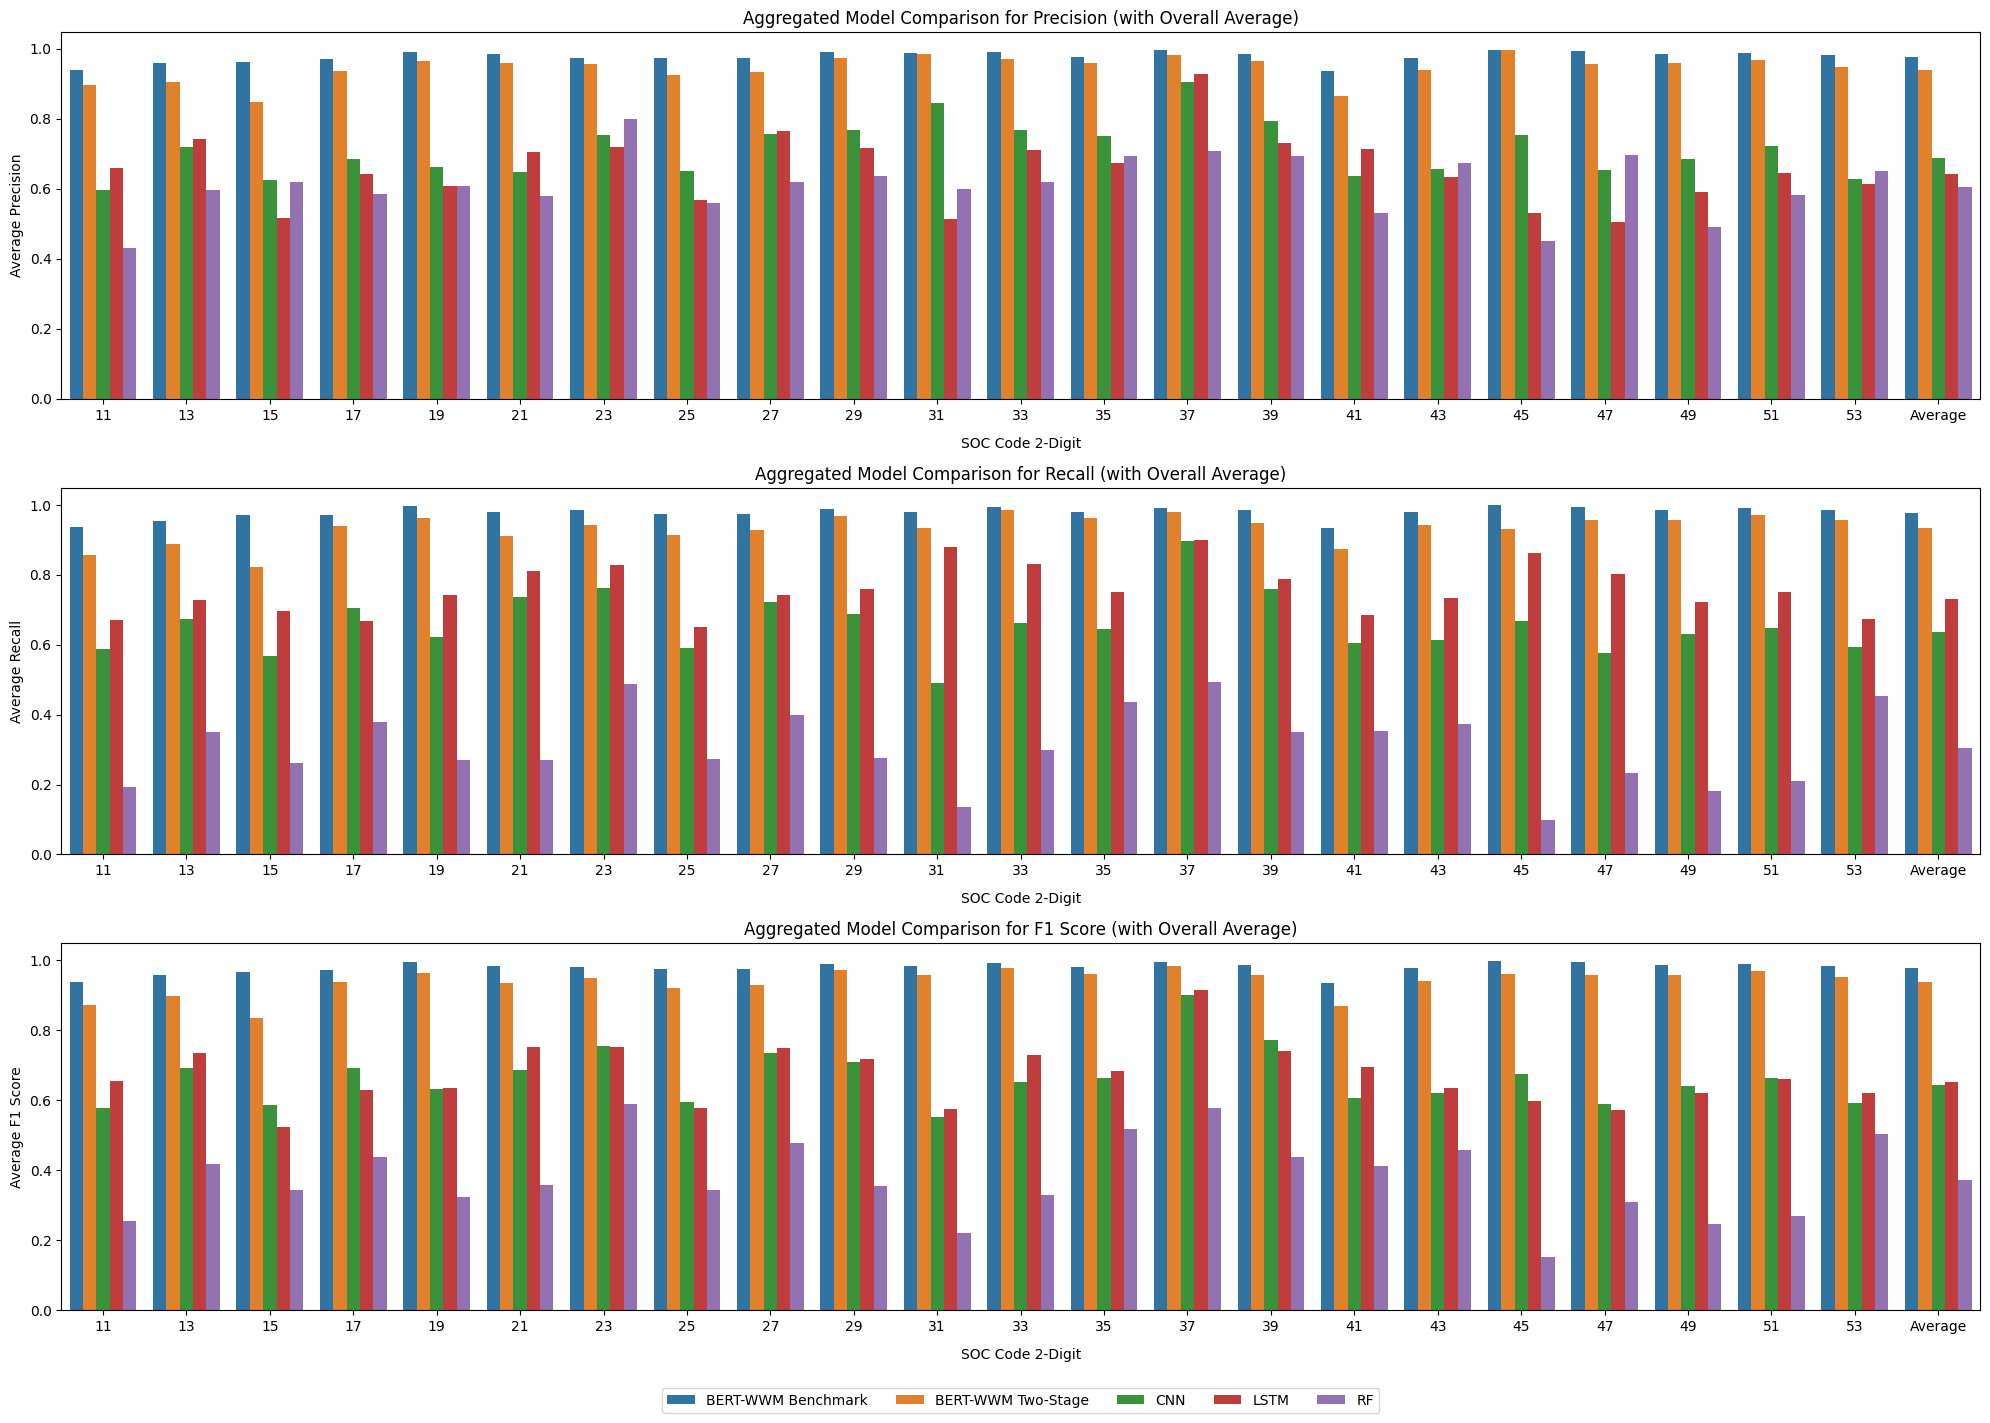

In [14]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Truncating SOC codes to their first 2 digits and calculating averages for each model

# # Truncating SOC codes to their first 2 digits and recalculating averages
# combined_df['SOC Code 2-Digit'] = combined_df['SOC Code'].str[:2]
# # Grouping by the 2-digit SOC code and the model, then calculating the mean
# grouped_df_2_digit = combined_df.groupby(['SOC Code 2-Digit', 'Model']).mean().reset_index()


# # Calculating the overall average for each metric for each model
# overall_avg_df = combined_df.groupby('Model').mean().reset_index()
# # Adding a marker for overall averages in the 'SOC Code 4-Digit' column
# overall_avg_df['SOC Code 2-Digit'] = 'Average'

# # Adding the overall average data to the 2-digit grouped data
# final_df_2_digit = pd.concat([overall_avg_df, grouped_df_2_digit], ignore_index=True)
# # Reordering the dataframe to have the overall average as the first bar
# final_df_2_digit = final_df_2_digit.sort_values(by=['SOC Code 2-Digit', 'Model'])

# # Adjusting the visualizations to address the issues:
# # 1. Fixing the overlap issue by adjusting the gap between the x-axis labels and titles.
# # 2. Removing the legends from the first two subfigures and keeping only one unified legend at the bottom.

# plt.figure(figsize=(20, 15))

# # Adjusted Aggregated Precision Plot
# plt.subplot(3, 1, 1)
# ax1 = sns.barplot(x='SOC Code 2-Digit', y='Precision', hue='Model', data=final_df_2_digit)
# plt.title('Aggregated Model Comparison for Precision (with Overall Average)')
# plt.ylabel('Average Precision')
# plt.xticks(rotation=0)

# # Adjusting layout to fix overlap
# ax1.xaxis.labelpad = 10
# ax1.legend().remove()  # Removing the legend from the first subfigure

# # Adjusted Aggregated Recall Plot
# plt.subplot(3, 1, 2)
# ax2 = sns.barplot(x='SOC Code 2-Digit', y='Recall', hue='Model', data=final_df_2_digit)
# plt.title('Aggregated Model Comparison for Recall (with Overall Average)')
# plt.ylabel('Average Recall')
# plt.xticks(rotation=0)

# # Adjusting layout to fix overlap
# ax2.xaxis.labelpad = 10
# ax2.legend().remove()  # Removing the legend from the second subfigure

# # Adjusted Aggregated F1 Score Plot
# plt.subplot(3, 1, 3)
# ax3 = sns.barplot(x='SOC Code 2-Digit', y='F1 Score', hue='Model', data=final_df_2_digit)
# plt.title('Aggregated Model Comparison for F1 Score (with Overall Average)')
# plt.ylabel('Average F1 Score')
# plt.xticks(rotation=0)

# # Adjusting layout to fix overlap
# ax3.xaxis.labelpad = 10

# # Moving the unified legend to the bottom of the figure
# handles, labels = ax3.get_legend_handles_labels()
# plt.legend(handles=handles, labels=labels, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=len(labels))

# plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.show()


#### Comparison Figure

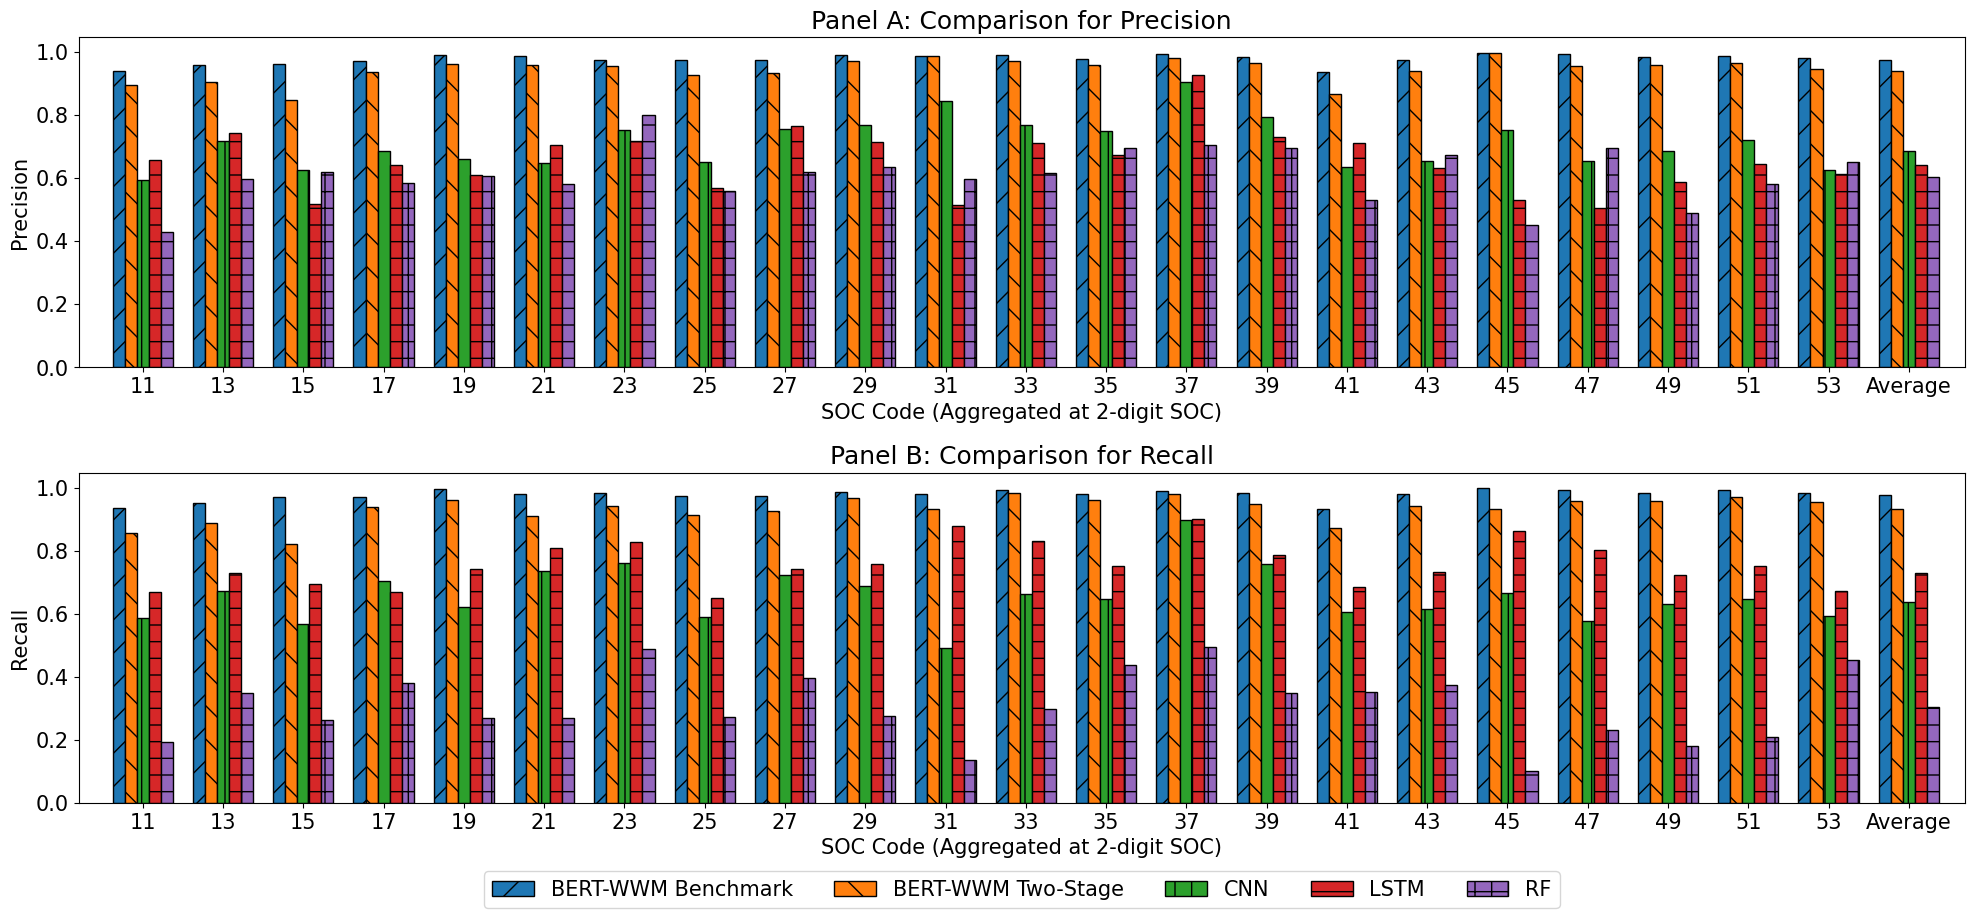

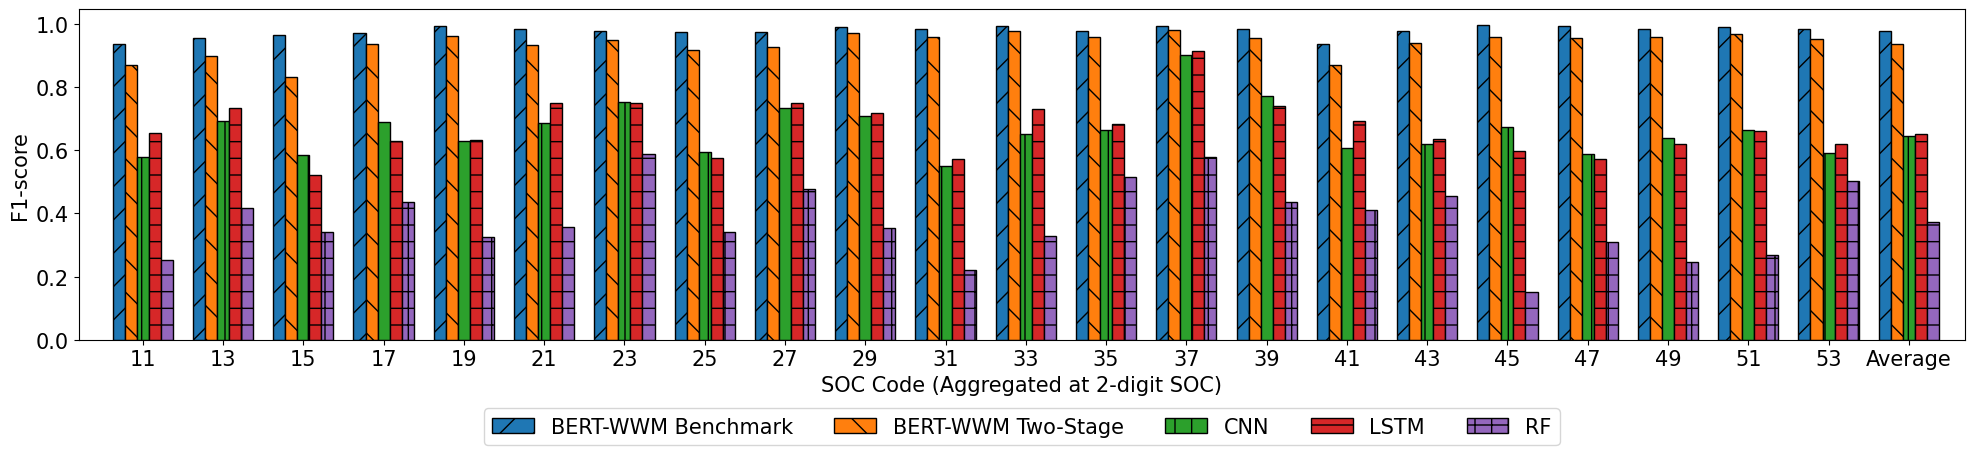

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Truncating SOC codes to their first 2 digits and calculating averages for each model

# Truncating SOC codes to their first 2 digits and recalculating averages
combined_df['SOC Code 2-Digit'] = combined_df['SOC Code'].str[:2]
# Grouping by the 2-digit SOC code and the model, then calculating the mean
grouped_df_2_digit = combined_df.groupby(['SOC Code 2-Digit', 'Model']).mean(numeric_only=True).reset_index()

# Calculating the overall average for each metric for each model
overall_avg_df = combined_df.groupby('Model').mean(numeric_only=True).reset_index()
# Adding a marker for overall averages in the 'SOC Code 2-Digit' column
overall_avg_df['SOC Code 2-Digit'] = 'Average'

# Adding the overall average data to the 2-digit grouped data
final_df_2_digit = pd.concat([overall_avg_df, grouped_df_2_digit], ignore_index=True)
# Reordering the dataframe to have the overall average as the first bar
final_df_2_digit = final_df_2_digit.sort_values(by=['SOC Code 2-Digit', 'Model'])

# Define a set of patterns to use for distinguishing different models
patterns = ['/', '\\', '|', '-', '+']

# Preparing the data for each model separately to apply patterns
models = final_df_2_digit['Model'].unique()
dfs = {model: final_df_2_digit[final_df_2_digit['Model'] == model] for model in models}

# Extracting SOC code labels
soc_code_labels = final_df_2_digit['SOC Code 2-Digit'].unique()

# Setting larger font sizes
plt.rcParams.update({'font.size': 15})  # Adjust this value as needed

# Function to plot bars with optimized x-axis range
def plot_with_optimized_x_axis(ax, metric, x_labels):
    # Number of unique SOC codes
    n_soc_codes = len(x_labels)
    # Total number of bars per group
    n_bars = len(models)
    # Calculating the width for each bar
    bar_width = 0.15

    # Positions for each model
    positions = range(n_soc_codes)

    for i, (model, pattern) in enumerate(zip(models, patterns)):
        model_df = final_df_2_digit[final_df_2_digit['Model'] == model]
        # Calculating the x position for each bar
        bar_positions = [x + bar_width * i for x in positions]
        ax.bar(bar_positions, model_df[metric], width=bar_width, label=model, hatch=pattern, edgecolor='black')

    # Adjusting the x-axis range
    ax.set_xlim([-0.5, n_soc_codes - 0])
    mid_positions = [x + bar_width * (len(models) - 1) / 2 for x in positions]
    ax.set_xticks(mid_positions)
    ax.set_xticklabels(x_labels, rotation=0)

# First figure: Panel A (Precision) and Panel B (Recall)
plt.figure(figsize=(20, 10))

# Plotting Precision (Panel A)
ax1 = plt.subplot(2, 1, 1)
plot_with_optimized_x_axis(ax1, 'Precision', soc_code_labels)
ax1.set_title('Panel A: Comparison for Precision')
ax1.set_ylabel('Precision')
ax1.set_xlabel('SOC Code (Aggregated at 2-digit SOC)')

# Plotting Recall (Panel B)
ax2 = plt.subplot(2, 1, 2)
plot_with_optimized_x_axis(ax2, 'Recall', soc_code_labels)
ax2.set_title('Panel B: Comparison for Recall')
ax2.set_ylabel('Recall')
ax2.set_xlabel('SOC Code (Aggregated at 2-digit SOC)')

# Adding legend for the first figure
handles, labels = ax2.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=len(labels))

# Adjusting the layout for the first figure
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Second figure: Panel C (F1 Score)
plt.figure(figsize=(20, 5))

# Plotting F1 Score (Panel C)
ax3 = plt.subplot(1, 1, 1)
plot_with_optimized_x_axis(ax3, 'F1 Score', soc_code_labels)
ax3.set_title('')
ax3.set_ylabel('F1-score')
ax3.set_xlabel('SOC Code (Aggregated at 2-digit SOC)')

# Adjusting the layout and legend for the second figure
handles, labels = ax3.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=len(labels))

plt.tight_layout()
plt.show()
